# MOMA-AC Coordination Bottleneck — HalfCheetah 2-Agent Baseline

## Project goal
Extend MOMA-AC (Callaghan et al., Nov 2025) — a preference-conditioned,
centralized-critic/decentralized-actor framework for multi-objective
multi-agent locomotion — with a tunable centralized coordination signal `z^(k)`.
The core research question: **does the amount of inter-limb information needed
for coordinated locomotion depend on the task objective (preference vector `w`)?**
Secondary question: what does the coordination signal actually encode, and does
that change with `w` (via linear probes, later)?

This notebook currently builds and validates the **k=0 fully-decentralized
baseline** — no coordination signal, no `w`-conditioning yet. To be implemented.

## Pivot away from original framing of contribution

You know the feeling when you think you have a pretty good new idea, and later find out that not only has someone already come up with it, but that they came up with it six years ago?

The original proposal framed the contribution as the architecture itself —
a novel tunable centralization encoder `z^(k)` that interpolates between fully
decentralized and fully centralized execution, evaluated against MOMA-AC with
and without a training critic.

A literature check found that this architectural idea has substantial
precedent: information-bottleneck approaches to MARL communication (Wang et al.,
ICML 2020) already implement essentially this mechanism — a learned, compressed
message between agents with a tunable bottleneck size — and there are further
follow-ups using adaptive/dynamic bottlenecks (vector-quantization-based,
gated/pruned messages, etc.). A reviewer familiar with this literature would
likely see "tunable degree of centralization" as an existing idea applied to a
new base algorithm, not a new contribution in itself.

Also deprioritized the "with vs. without training critic" comparison as a
primary experiment. Removing the critic and varying `k` at the same time
changes two variables at once, making it hard to attribute any performance
difference to either factor cleanly. Now hold the centralized critic fixed
across every condition and treat critic-removal as a later ablation, not part
of the core result.

**What was kept:** the encoder architecture, the k-sweep, the CTDE structure —
none of this required throwing away code or the existing baseline.

Changed framing of the primary research question. Instead of
claiming novelty in the bottleneck mechanism, using it as a measurement
tool to ask a question couldn't find addressed in the literature:

> Does the amount of inter-limb coordination needed for effective locomotion
> depend on the task objective being optimized (the preference vector `w`)?
> E.g., does a speed-maximizing gait require more shared information between
> legs than an energy-minimizing gait?

This reframing also promotes the linear-probe analysis (originally listed as
an optional extension) to a primary result: not just *how much* information
is shared at each `k`, but *what* the coordination signal encodes, and whether
that content shifts with `w`. This is a more defensible, narrowly-scoped
novelty claim for a 6-month project than "built a new bottleneck," and it
reuses all of the infrastructure already built below.

## Environment setup
- Env: MaMuJoCo HalfCheetah, 2 agents (`agent_conf="2x3"`) — back leg / front leg,
  3 joints each, `agent_obsk=0` (minimal local neighborhood).
- **Key finding:** even at `agent_obsk=0`, MaMuJoCo shares 5 torso-state values
  with both agents (indices 0,1,8,9,10 of the 17-dim global obs: torso height,
  pitch, forward velocity, vertical velocity, pitch rate). This isn't a bug —
  it's how MaMuJoCo partitions a body whose torso both legs act on.
- **Design decision (can change if needed):** Treat this shared torso block as
  a permanent part of every agent's "local" observation, in every condition
  including k=0. The coordination signal `z` will therefore only ever need to
  carry genuinely new *inter-limb* information (what the other leg is doing),
  not torso state — this is the more physically honest reading of "local"
  (like an onboard IMU) and avoids modifying the environment.

## Architecture (current, k=0 only)
- Two independent `GaussianActor` policies (one per agent), each mapping its
  own 11-dim local observation → 3-dim joint torques.
- One shared `CentralizedCritic` over the full 17-dim reconstructed global state.
- Trained with a from-scratch PyTorch PPO implementation (independent actor
  updates, shared centralized critic, GAE advantages). **Not using
  stable-baselines3** — SB3 doesn't natively support PettingZoo multi-agent
  envs or custom info-routing (`z`, `w`), so a custom loop was necessary.
- Reward: HalfCheetah's default (forward velocity − control cost), shared
  identically across both agents. Not yet objective-decomposed for `w`.

## Notebook structure
- Cells 0-1: headless rendering config (`MUJOCO_GL=egl`) + package installs.
  **Cell 0 must run before any MuJoCo import**, anywhere in the runtime.
- Cells 2-4: environment instantiation + observation partition inspection
  (this is where the torso-leak finding above came from).
- Cell 5: random-policy rollout + video (`cheetah_random.mp4`) — untrained
  reference point.
- Cells 8-11: networks, rollout buffer/GAE, rollout collection, PPO update.
- Cell 12: training loop (tracks return/loss history for plotting).
- Cell 13: training curve plots.
- Cell 14: trained-policy rollout + video (`cheetah_rollout.mp4`), using
  deterministic (mean) actions for eval.

## Status as of last run
- Full pipeline runs end-to-end without errors.
- 200 epochs (~400k steps): avg return climbed from ~-400 to ~600-900,
  noisy but clearly trending upward — confirms obs partitioning, action
  assembly, and the PPO update are all correct.
- **Open question:** the trained-policy video still looks visibly
  uncoordinated. Investigating whether this is (a) undertraining — 400k
  steps is on the low end for HalfCheetah, and decentralized actors likely
  need more than single-agent PPO does, (b) a genuine decentralized-
  coordination failure mode (which would actually be a relevant baseline
  result for this project), or (c) an action-scaling bug — actor outputs an
  unbounded Gaussian mean that isn't currently squashed to the env's
  expected [-1, 1] range via `tanh`.

## Not yet implemented
- Checkpoint saving/loading (`torch.save`/`load_state_dict`) for the k=0
  baseline once it plateaus.
- `w` (preference vector) conditioning — reward decomposition into
  (velocity, -control cost) components, `w · reward_components`, and
  concatenating `w` onto actor inputs. Agreed to add this *after* confirming
  the k=0 baseline trains correctly (in progress above).
- Coordination encoder `c_ψ(o_global, w) → z^(k)` and the k-sweep
  (k ∈ {0,1,2,4,8,full}).
- Linear probes on `z`, robustness/perturbation ablation, modular
  single-agent comparison — all planned as later phases.

## Related work (for novelty framing)
- MOMA-AC (Callaghan et al., arXiv:2511.18181, Nov 2025) — the base
  framework being extended; currently has no centralization-tuning mechanism.
- Information-bottleneck MARL communication (Wang et al., ICML 2020, and
  related dynamic/adaptive-bottleneck follow-ups) — closest architectural
  precedent for `z^(k)`; the bottleneck mechanism itself is not new.
- Our contribution is scoped narrowly: applying a tunable coordination
  signal to MOMA-AC specifically, in a locomotion domain, studying whether
  coordination need interacts with `w` — not a new bottleneck architecture.

In [ ]:
#Cell 0: Switching MuJoCo's rendering backend to EGL
import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

In [ ]:
#Cell 1: Install dependencies
#~30s runtime
!apt-get update -qq && apt-get install -qq -y libegl1 libgl1 libglx-mesa0 libosmesa6 2>&1 | tail -5

%pip install -q gymnasium-robotics mujoco "gymnasium[mujoco]" stable-baselines3 pettingzoo torch imageio imageio-ffmpeg

import importlib.metadata as metadata

packages = ["gymnasium_robotics", "gymnasium", "pettingzoo", "mujoco", "stable_baselines3", "torch"]

for package in packages:
    print(f"{package}: {metadata.version(package)}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
#Cell 2: Instantiate 2-agent Half-cheetah environment
from gymnasium_robotics import mamujoco_v1

# 2 agents (front leg / back leg), 3 joints each
# agent_obsk=0 -> strictly local observations only (no neighbor-joint info)
env = mamujoco_v1.parallel_env(
    scenario="HalfCheetah",
    agent_conf="2x3",
    agent_obsk=0,
    render_mode=None,
)

obs, info = env.reset(seed=0)

print("Agents:", env.agents)
for agent in env.agents:
    print(f"\n{agent}")
    print("  obs space:", env.observation_space(agent))
    print("  act space:", env.action_space(agent))
    print("  obs sample shape:", obs[agent].shape)

In [ ]:
#Cell 3: Inspect what is inside each agent's observation
import numpy as np

np.set_printoptions(precision=3, suppress=True)

for agent in env.agents:
    print(f"{agent} obs ({obs[agent].shape[0]} values):")
    print(obs[agent])
    print()

In [ ]:
#Cell 4: Check MaMuJoCo's record of what each agent can see (need this as a starting point)
# Access the underlying observation partition MaMuJoCo built
unwrapped = env.unwrapped
print(unwrapped.possible_agents if hasattr(unwrapped, "possible_agents") else "n/a")

try:
    print(unwrapped.obs_mapping)
except AttributeError:
    print([a for a in dir(unwrapped) if "obs" in a.lower() or "partition" in a.lower() or "map" in a.lower()])

In [ ]:
#Cell 5: Random rollout sanity check + render to video
#~15s runtime
%pip install -q imageio imageio-ffmpeg

import imageio

render_env = mamujoco_v1.parallel_env(
    scenario="HalfCheetah",
    agent_conf="2x3",
    agent_obsk=0,
    render_mode="rgb_array",
)

obs, info = render_env.reset(seed=0)
agent_list = list(render_env.agents)
frames = []

for step in range(50):
    frames.append(render_env.render())
    actions = {agent: render_env.action_space(agent).sample() for agent in agent_list}
    obs, rewards, terminations, truncations, infos = render_env.step(actions)
    if step == 0:
        print("Sample actions:", actions)
        print("Sample rewards:", rewards)
    if all(terminations.values()) or all(truncations.values()):
        break

render_env.close()
imageio.mimsave("cheetah_random.mp4", frames, fps=30)
print("Rollout completed without error")

from IPython.display import Video
Video("cheetah_random.mp4", embed=True)

Sample actions: {'agent_0': array([0.704, 0.061, 0.527], dtype=float32), 'agent_1': array([-0.053,  0.879,  0.018], dtype=float32)}
Sample rewards: {'agent_0': np.float64(0.22801327328378243), 'agent_1': np.float64(0.22801327328378243)}
Rollout completed without error


In [ ]:
#Cell 6: Identify each of the 5 shared values
unwrapped = env.unwrapped

print("agent_action_partitions:")
print(unwrapped.agent_action_partitions)
print()

print("observation_factorization:")
print(unwrapped.observation_factorization)
print()

# This should show, per agent, which global obs indices/categories map to it
try:
    print("global obs mapping:")
    print(unwrapped.create_observation_mapping())
except Exception as e:
    print("create_observation_mapping needs args or errored:", e)

agent_action_partitions:
[(bthigh, bshin, bfoot), (fthigh, fshin, ffoot)]

observation_factorization:
{'agent_0': array([ 4, 13,  3, 12,  2, 11,  0,  1,  8,  9, 10]), 'agent_1': array([ 7, 16,  6, 15,  5, 14,  0,  1,  8,  9, 10])}

global obs mapping:
{'agent_0': array([ 4, 13,  3, 12,  2, 11,  0,  1,  8,  9, 10]), 'agent_1': array([ 7, 16,  6, 15,  5, 14,  0,  1,  8,  9, 10])}


In [ ]:
#Cell 7: Cross-reference against known HalfCheetah global state
# Grab the full underlying single-agent global observation for comparison
global_obs = unwrapped.map_local_observations_to_global_state(obs)
print("Reconstructed/global obs:", global_obs)
print("Global obs shape:", global_obs.shape if hasattr(global_obs, "shape") else len(global_obs))

Reconstructed/global obs: [-0.145 -0.022  0.365  0.098  0.095 -0.05  -0.055 -0.101  0.318 -0.374
 -1.12   7.545 -1.433  2.924  4.649  0.894  7.659]
Global obs shape: (17,)


In [ ]:
#Cell 8: Networks -- per-agent actors + centralized critic
#~5s runtime
import torch
import torch.nn as nn
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def mlp(sizes, activation=nn.Tanh, output_activation=nn.Identity):
    layers = []
    for i in range(len(sizes) - 1):
        act = activation if i < len(sizes) - 2 else output_activation
        layers += [nn.Linear(sizes[i], sizes[i+1]), act()]
    return nn.Sequential(*layers)

class GaussianActor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(64, 64)):
        super().__init__()
        self.mu_net = mlp([obs_dim, *hidden, act_dim])
        self.log_std = nn.Parameter(-0.5 * torch.ones(act_dim))

    def forward(self, obs):
        mu = self.mu_net(obs)
        std = torch.exp(self.log_std)
        dist = torch.distributions.Normal(mu, std)
        return dist

class CentralizedCritic(nn.Module):
    def __init__(self, global_obs_dim, hidden=(64, 64)):
        super().__init__()
        self.v_net = mlp([global_obs_dim, *hidden, 1])

    def forward(self, global_obs):
        return self.v_net(global_obs).squeeze(-1)

# Instantiate: one actor per agent, one shared centralized critic
obs_dim = env.observation_space("agent_0").shape[0]   # 11
act_dim = env.action_space("agent_0").shape[0]        # 3
global_obs_dim = 17

actors = {agent: GaussianActor(obs_dim, act_dim).to(device) for agent in env.agents}
critic = CentralizedCritic(global_obs_dim).to(device)

actor_params = [p for a in actors.values() for p in a.parameters()]
actor_optimizer = torch.optim.Adam(actor_params, lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=1e-3)

print("Actor param count (per agent):", sum(p.numel() for p in actors["agent_0"].parameters()))
print("Critic param count:", sum(p.numel() for p in critic.parameters()))

Actor param count (per agent): 5126
Critic param count: 5377


In [ ]:
#Cell 9: Rollout buffer + GAE
class RolloutBuffer:
    def __init__(self, size, obs_dim, act_dim, global_obs_dim, n_agents, gamma=0.99, lam=0.95):
        self.obs = {a: np.zeros((size, obs_dim), dtype=np.float32) for a in range(n_agents)}
        self.acts = {a: np.zeros((size, act_dim), dtype=np.float32) for a in range(n_agents)}
        self.logp = {a: np.zeros(size, dtype=np.float32) for a in range(n_agents)}
        self.rews = np.zeros(size, dtype=np.float32)       # shared reward (HalfCheetah gives identical reward to both agents)
        self.global_obs = np.zeros((size, global_obs_dim), dtype=np.float32)
        self.vals = np.zeros(size, dtype=np.float32)
        self.gamma, self.lam = gamma, lam
        self.ptr, self.max_size = 0, size

    def store(self, obs_dict, act_dict, logp_dict, rew, global_obs, val):
        for i, a in enumerate(obs_dict.keys()):
            self.obs[i][self.ptr] = obs_dict[a]
            self.acts[i][self.ptr] = act_dict[a]
            self.logp[i][self.ptr] = logp_dict[a]
        self.rews[self.ptr] = rew
        self.global_obs[self.ptr] = global_obs
        self.vals[self.ptr] = val
        self.ptr += 1

    def compute_advantages(self, last_val=0.0):
        adv = np.zeros(self.max_size, dtype=np.float32)
        last_gae = 0.0
        for t in reversed(range(self.max_size)):
            next_val = self.vals[t+1] if t < self.max_size - 1 else last_val
            delta = self.rews[t] + self.gamma * next_val - self.vals[t]
            last_gae = delta + self.gamma * self.lam * last_gae
            adv[t] = last_gae
        returns = adv + self.vals
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        return adv, returns

    def reset(self):
        self.ptr = 0

In [ ]:
#Cell 10: Rollout collection
def collect_rollout(env, actors, critic, buffer, rollout_steps):
    obs, info = env.reset()
    agent_list = list(env.agents)  # cache once, right after reset
    ep_returns, ep_ret = [], 0.0

    for t in range(rollout_steps):
        act_dict, logp_dict = {}, {}
        with torch.no_grad():
            for agent in agent_list:
                obs_t = torch.as_tensor(obs[agent], dtype=torch.float32, device=device)
                dist = actors[agent](obs_t)
                action = dist.sample()
                logp = dist.log_prob(action).sum(-1)
                act_dict[agent] = action.cpu().numpy()
                logp_dict[agent] = logp.item()

            global_obs = env.unwrapped.map_local_observations_to_global_state(obs)
            global_obs_t = torch.as_tensor(global_obs, dtype=torch.float32, device=device)
            val = critic(global_obs_t).item()

        next_obs, rewards, terms, truncs, infos = env.step(act_dict)
        rew = rewards[agent_list[0]]  # shared reward, using cached agent name

        buffer.store(obs, act_dict, logp_dict, rew, global_obs, val)
        ep_ret += rew

        done = all(terms.values()) or all(truncs.values())

        if done:
            obs, info = env.reset()
            agent_list = list(env.agents)  # re-cache after reset
            ep_returns.append(ep_ret)
            ep_ret = 0.0
        else:
            obs = next_obs

    with torch.no_grad():
        global_obs = env.unwrapped.map_local_observations_to_global_state(obs)
        last_val = critic(torch.as_tensor(global_obs, dtype=torch.float32, device=device)).item()

    return last_val, ep_returns

In [ ]:
#Cell 11: PPO update step
def ppo_update(buffer, actors, critic, actor_optimizer, critic_optimizer,
               last_val, clip_ratio=0.2, train_iters=10):
    adv, returns = buffer.compute_advantages(last_val)
    adv_t = torch.as_tensor(adv, dtype=torch.float32, device=device)
    ret_t = torch.as_tensor(returns, dtype=torch.float32, device=device)
    global_obs_t = torch.as_tensor(buffer.global_obs, dtype=torch.float32, device=device)

    for _ in range(train_iters):
        # Critic update
        critic_optimizer.zero_grad()
        values = critic(global_obs_t)
        critic_loss = ((values - ret_t) ** 2).mean()
        critic_loss.backward()
        critic_optimizer.step()

        # Actor updates (independent per agent)
        actor_optimizer.zero_grad()
        total_actor_loss = 0.0
        for i, agent in enumerate(env.agents):
            obs_t = torch.as_tensor(buffer.obs[i], dtype=torch.float32, device=device)
            act_t = torch.as_tensor(buffer.acts[i], dtype=torch.float32, device=device)
            old_logp_t = torch.as_tensor(buffer.logp[i], dtype=torch.float32, device=device)

            dist = actors[agent](obs_t)
            logp = dist.log_prob(act_t).sum(-1)
            ratio = torch.exp(logp - old_logp_t)

            clip_adv = torch.clamp(ratio, 1 - clip_ratio, 1 + clip_ratio) * adv_t
            actor_loss = -torch.min(ratio * adv_t, clip_adv).mean()
            total_actor_loss += actor_loss

        total_actor_loss.backward()
        actor_optimizer.step()

    return critic_loss.item(), total_actor_loss.item()

In [ ]:
#Cell 12: Training loop
#Note: took me ~9 minutes to run this cell
rollout_steps = 2048
n_epochs = 200

buffer = RolloutBuffer(rollout_steps, obs_dim, act_dim, global_obs_dim, n_agents=2)

history = {"epoch": [], "avg_return": [], "critic_loss": [], "actor_loss": []}

for epoch in range(n_epochs):
    buffer.reset()
    last_val, ep_returns = collect_rollout(env, actors, critic, buffer, rollout_steps)
    critic_loss, actor_loss = ppo_update(buffer, actors, critic, actor_optimizer, critic_optimizer, last_val)

    avg_ret = np.mean(ep_returns) if ep_returns else np.nan
    history["epoch"].append(epoch)
    history["avg_return"].append(avg_ret)
    history["critic_loss"].append(critic_loss)
    history["actor_loss"].append(actor_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:4d} | episodes: {len(ep_returns):3d} | avg return: {avg_ret:8.2f} | "
              f"critic loss: {critic_loss:.3f} | actor loss: {actor_loss:.3f}")

Epoch    0 | episodes:   2 | avg return:  -275.83 | critic loss: 41.055 | actor loss: -0.027
Epoch   10 | episodes:   2 | avg return:  -170.91 | critic loss: 11.962 | actor loss: -0.012
Epoch   20 | episodes:   2 | avg return:   -73.27 | critic loss: 26.533 | actor loss: -0.018
Epoch   30 | episodes:   2 | avg return:  -233.44 | critic loss: 15.181 | actor loss: -0.015
Epoch   40 | episodes:   2 | avg return:  -171.40 | critic loss: 14.076 | actor loss: -0.017
Epoch   50 | episodes:   2 | avg return:   -28.23 | critic loss: 26.812 | actor loss: -0.015
Epoch   60 | episodes:   2 | avg return:    34.46 | critic loss: 21.559 | actor loss: -0.019
Epoch   70 | episodes:   2 | avg return:   227.05 | critic loss: 23.668 | actor loss: -0.016
Epoch   80 | episodes:   2 | avg return:   407.71 | critic loss: 39.859 | actor loss: -0.015
Epoch   90 | episodes:   2 | avg return:   421.13 | critic loss: 25.308 | actor loss: -0.016
Epoch  100 | episodes:   2 | avg return:   447.13 | critic loss: 43.59

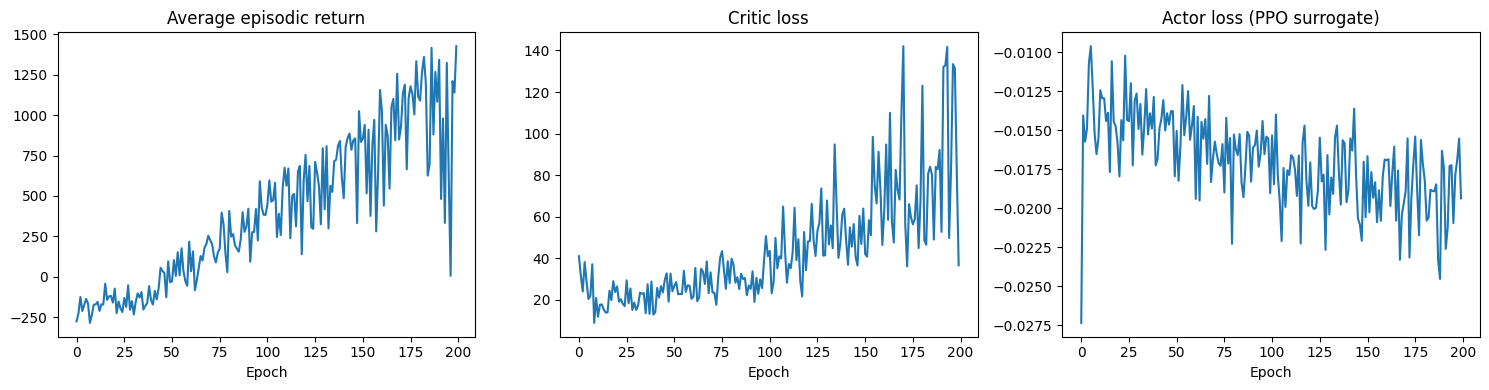

In [ ]:
#Cell 13: Plotting cell
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["epoch"], history["avg_return"])
axes[0].set_title("Average episodic return")
axes[0].set_xlabel("Epoch")

axes[1].plot(history["epoch"], history["critic_loss"])
axes[1].set_title("Critic loss")
axes[1].set_xlabel("Epoch")

axes[2].plot(history["epoch"], history["actor_loss"])
axes[2].set_title("Actor loss (PPO surrogate)")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [ ]:
#Cell 14: Render rollout to video
%pip install -q imageio imageio-ffmpeg

import imageio

render_env = mamujoco_v1.parallel_env(
    scenario="HalfCheetah",
    agent_conf="2x3",
    agent_obsk=0,
    render_mode="rgb_array",
)

obs, info = render_env.reset(seed=42)
agent_list = list(render_env.agents)
frames = []

with torch.no_grad():
    for t in range(1000):
        frames.append(render_env.render())
        act_dict = {}
        for agent in agent_list:
            obs_t = torch.as_tensor(obs[agent], dtype=torch.float32, device=device)
            dist = actors[agent](obs_t)
            act_dict[agent] = dist.mean.cpu().numpy()  # deterministic (mean) action for eval
        obs, rewards, terms, truncs, infos = render_env.step(act_dict)
        if all(terms.values()) or all(truncs.values()):
            break

render_env.close()
imageio.mimsave("cheetah_rollout.mp4", frames, fps=30)

from IPython.display import Video
Video("cheetah_rollout.mp4", embed=True)